# Import

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from kneed import KneeLocator

# Dataset

In [12]:
df = pd.read_csv("dvf_2025_mutations_propres.csv", dtype={"code_dept": str})

# Nettoyage 

In [13]:
df = df[df["retenue_stats"]]
df = df[df["valeur_fonciere"] > 0].copy()

df["surface_bati"] = df[["surf_maison", "surf_appartement", "surf_local_pro"]].sum(axis=1)
df["terrain_total"] = df["terrain_total"].fillna(0)
df["nb_pieces"] = df["nb_pieces"].fillna(0)
df["code_dept"] = df["code_dept"].astype(str)

df["prix_m2"] = (
    df["prix_m2_fiable"]
    .fillna(df["prix_m2_terrain"])
    .fillna(df["prix_m2_pro"])
)

df = df.dropna(subset=["prix_m2"]).reset_index(drop=True)

print(f"Nombre total de biens : {len(df)}")
print(df["type_bien"].value_counts(dropna=False))

Nombre total de biens : 981878
type_bien
Maison                           364975
Appartement                      340965
Terrain agricole                 117091
Local pro                         47464
Terrain non bâti (sol/jardin)     41865
Terrain à bâtir                   37006
Forêt / bois                      22891
Appartement neuf (VEFA)            6576
Terrain autre                      3045
Name: count, dtype: int64


# Echantillon (seulement si le pc n'a pas assez de RAM)

In [14]:
df = df.sample(n=30000, random_state=42).reset_index(drop=True)
print(f"Nombre de biens apres echantillonnage : {len(df)}")

Nombre de biens apres echantillonnage : 30000


# Normalisation

In [15]:
dept_to_region = {
    # Auvergne-Rhone-Alpes
    "01": "ARA", "03": "ARA", "07": "ARA", "15": "ARA", "26": "ARA",
    "38": "ARA", "42": "ARA", "43": "ARA", "63": "ARA", "69": "ARA",
    "73": "ARA", "74": "ARA",
    # Bourgogne-Franche-Comte
    "21": "BFC", "25": "BFC", "39": "BFC", "58": "BFC", "70": "BFC",
    "71": "BFC", "89": "BFC", "90": "BFC",
    # Bretagne
    "22": "BRE", "29": "BRE", "35": "BRE", "56": "BRE",
    # Centre-Val de Loire
    "18": "CVL", "28": "CVL", "36": "CVL", "37": "CVL", "41": "CVL", "45": "CVL",
    # Corse
    "2A": "COR", "2B": "COR",
    # Grand Est
    "08": "GES", "10": "GES", "51": "GES", "52": "GES", "54": "GES",
    "55": "GES", "57": "GES", "67": "GES", "68": "GES", "88": "GES",
    # Hauts-de-France
    "02": "HDF", "59": "HDF", "60": "HDF", "62": "HDF", "80": "HDF",
    # Ile-de-France
    "75": "IDF", "77": "IDF", "78": "IDF", "91": "IDF", "92": "IDF",
    "93": "IDF", "94": "IDF", "95": "IDF",
    # Normandie
    "14": "NOR", "27": "NOR", "50": "NOR", "61": "NOR", "76": "NOR",
    # Nouvelle-Aquitaine
    "16": "NAQ", "17": "NAQ", "19": "NAQ", "23": "NAQ", "24": "NAQ",
    "33": "NAQ", "40": "NAQ", "47": "NAQ", "64": "NAQ", "79": "NAQ",
    "86": "NAQ", "87": "NAQ",
    # Occitanie
    "09": "OCC", "11": "OCC", "12": "OCC", "30": "OCC", "31": "OCC",
    "32": "OCC", "34": "OCC", "46": "OCC", "48": "OCC", "65": "OCC",
    "66": "OCC", "81": "OCC", "82": "OCC",
    # Pays de la Loire
    "44": "PDL", "49": "PDL", "53": "PDL", "72": "PDL", "85": "PDL",
    # Provence-Alpes-Cote d'Azur
    "04": "PAC", "05": "PAC", "06": "PAC", "13": "PAC", "83": "PAC", "84": "PAC",
    # DOM
    "971": "DOM", "972": "DOM", "973": "DOM", "974": "DOM", "976": "DOM",
}

df["region"] = df["code_dept"].map(dept_to_region)

depts_non_reconnus = df.loc[df["region"].isna(), "code_dept"].unique()

if len(depts_non_reconnus) > 0:
    print(f"Departements non reconnus : {depts_non_reconnus}")
    df["region"] = df["region"].fillna("AUTRE")

print(df["region"].value_counts())

region
IDF    4198
ARA    3849
NAQ    3379
OCC    3323
PAC    2793
HDF    2467
PDL    2132
BRE    1802
NOR    1629
BFC    1434
CVL    1226
GES    1218
DOM     369
COR     181
Name: count, dtype: int64


In [16]:
# Par département
# df_encoded = pd.get_dummies(
#     df, columns=["code_departement", "type_bien"], prefix=["dept", "type"]
# )

# Par région
df_encoded = pd.get_dummies(
    df, columns=["region", "type_bien"], prefix=["region", "bien"]
)

nb_dimensions = [
    "valeur_fonciere", "prix_m2", "surface_bati",
    "nb_pieces", "terrain_total",
]

# col_dimensions = nb_dimensions + [
#     c for c in df_encoded.columns if c.startswith("dept_") or c.startswith("type_")
# ]

col_dimensions = nb_dimensions + [
    c for c in df_encoded.columns if c.startswith("region_") or c.startswith("bien_")
]
 
X = df_encoded[col_dimensions].values

X = StandardScaler().fit_transform(X)


# Choix paramètre : eps (k-distance graphe) et minPts (nb_dimensions + 1)

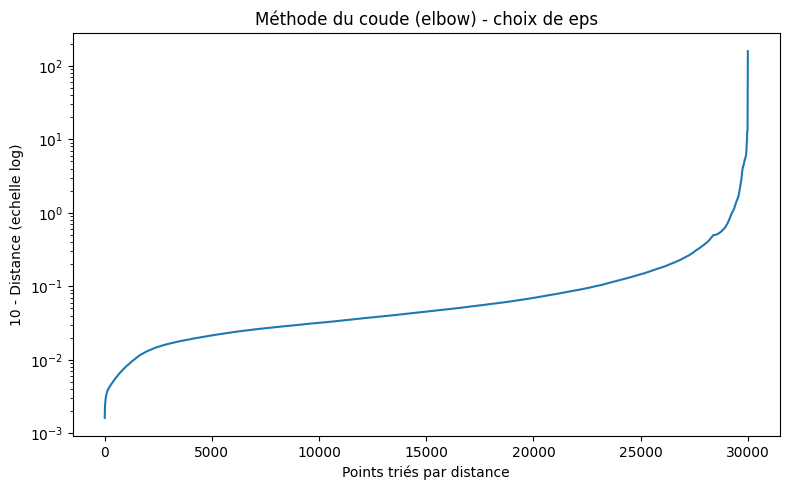

eps (automatique) : 13.2601
min_samples : 10


In [17]:
min_samples = 2 * len(nb_dimensions) 
neighbors_fit = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = neighbors_fit.kneighbors(X)
k_distances = np.sort(distances[:, min_samples-1])
 
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.yscale("log")
plt.xlabel("Points triés par distance")
plt.ylabel(f"{min_samples} - Distance (echelle log)")
plt.title("Méthode du coude (elbow) - choix de eps")
plt.tight_layout()
plt.show()

#################

# Utiliser cette partie si eps est trop grand
# cut = int(len(k_distances) * 0.99) 
# k_distances_cut = k_distances[:cut]

# kneeLocator = KneeLocator( 
#     range(len(k_distances_cut)), k_distances_cut,
#     curve="convex", direction="increasing"
# )
# eps = k_distances_cut[kneeLocator.knee]

############

# Mettre en commentqire cette partie si on utilise le bloc de code du haut
kneeLocator = KneeLocator(
    range(len(k_distances)), k_distances,
    curve="convex", direction="increasing"
)

eps = k_distances[kneeLocator.knee]

###############

print(f"eps (automatique) : {eps:.4f}")
print(f"min_samples : {min_samples}")

# DBSCAN

In [18]:
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

df["cluster_dbscan"] = labels
 
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

n_noise_ = list(labels).count(-1)

print(f"Nombre de clusters : {n_clusters_}")
print(f"Nombre de points de bruit (biens atypiques) : {n_noise_} "
      f"({100 * n_noise_ / len(labels):.1f}%)")
 

Nombre de clusters : 2
Nombre de points de bruit (biens atypiques) : 11 (0.0%)


# Visualisation plt

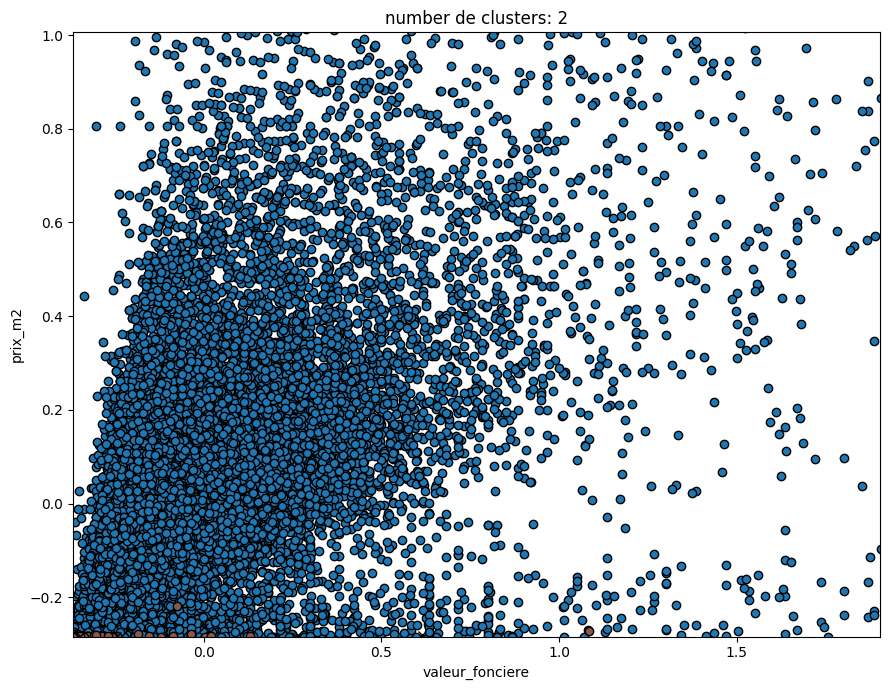

In [19]:
col_x = col_dimensions.index("valeur_fonciere")
col_y = col_dimensions.index("prix_m2")
 
unique_labels = set(labels)
colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
plt.figure(figsize=(9, 7))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = "k"
 
    class_member_mask = (labels == k)
 
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, col_x], xy[:, col_y], "o", markerfacecolor=col,
              markeredgecolor="k", markersize=6, label=f"Cluster {k}" if k != -1 else "Bruit")
 
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, col_x], xy[:, col_y], "x", markerfacecolor=col,
              markeredgecolor="k", markersize=6)
 
plt.xlabel("valeur_fonciere")
plt.ylabel("prix_m2")
plt.title("number de clusters: %d" % n_clusters_)
# plt.legend(fontsize=8)

# zoom
x_min, x_max = np.percentile(X[:, col_x], [1, 99])
y_min, y_max = np.percentile(X[:, col_y], [1, 99])
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)


plt.tight_layout()
plt.show()
 

# Silhouette score

In [20]:
mask_valid = labels != -1
if n_clusters_ >= 2 and mask_valid.sum() > n_clusters_:
    sc = metrics.silhouette_score(X[mask_valid], labels[mask_valid])
    print("Silhouette Coefficient (hors bruit): %0.2f" % sc)
else:
    print("Silhouette score non calculable (ajuster eps / min_samples).")

Silhouette Coefficient (hors bruit): 0.67
